[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatsubaraSoda/Notebook/blob/main/notebooks/%E7%89%A9%E7%90%86%E5%AD%A6/%E7%94%B5%E7%A3%81%E5%AD%A6/%E5%85%89%E5%AD%A6/%E5%87%A0%E4%BD%95%E5%85%89%E5%AD%A6/angular-deviation-expression.ipynb)

根据色散棱镜的偏向角公式

$$
\delta = \theta_{i1} + \arcsin \left[ \sin\alpha \left( n^2 - \sin^2\theta_{i1} \right)^{1/2} - \cos\alpha \sin\theta_{i1} \right] - \alpha
$$

在常量 $n = 1.5$、$\alpha = 60°$ 下，以第一入射角 $\theta_{i1}$ 为自变量、偏向角 $\delta$ 为因变量，绘制 $\delta(\theta_{i1})$ 曲线，并标出最小偏向角 $\delta_m$ 及其对应的 $\theta_{i1}$。

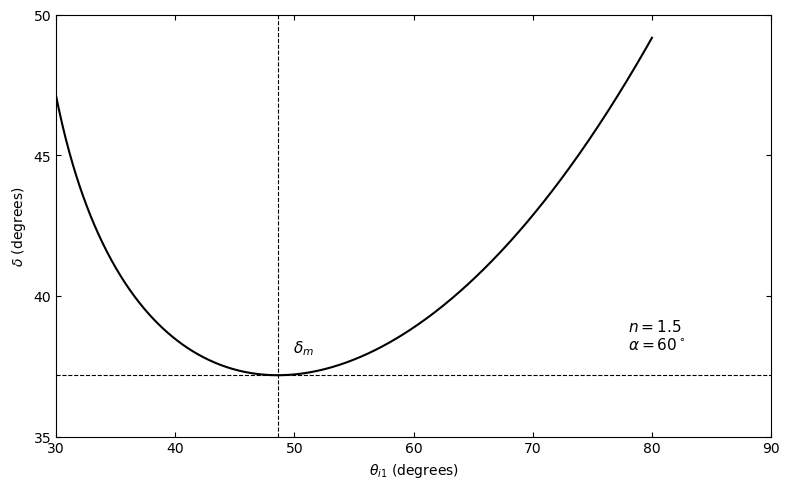

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 常量
n = 1.5
alpha_deg = 60.0

def delta_deg(theta_i1_deg):
    """偏向角 δ（度），自变量为第一入射角 θ_{i1}（度）。"""
    theta_i1 = np.deg2rad(theta_i1_deg)
    alpha = np.deg2rad(alpha_deg)
    arg = (
        np.sin(alpha) * np.sqrt(n**2 - np.sin(theta_i1) ** 2)
        - np.cos(alpha) * np.sin(theta_i1)
    )
    arg = np.clip(arg, -1.0, 1.0)
    return np.rad2deg(theta_i1 + np.arcsin(arg) - alpha)

theta_i1 = np.linspace(30, 80, 500)
delta = delta_deg(theta_i1)

idx_min = np.argmin(delta)
theta_m = theta_i1[idx_min]
delta_m = delta[idx_min]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(theta_i1, delta, color="k", linewidth=1.5)

ax.axvline(theta_m, color="k", linestyle="--", linewidth=0.8)
ax.axhline(delta_m, color="k", linestyle="--", linewidth=0.8)
ax.text(theta_m + 1.2, delta_m + 0.8, r"$\delta_m$", fontsize=11)

ax.set_xlim(30, 90)
ax.set_ylim(35, 50)
ax.set_xlabel(r"$\theta_{i1}$ (degrees)")
ax.set_ylabel(r"$\delta$ (degrees)")
ax.set_xticks(np.arange(30, 91, 10))
ax.set_yticks(np.arange(35, 51, 5))

ax.text(
    0.80, 0.20,
    rf"$n = {n}$" + "\n" + rf"$\alpha = {alpha_deg:.0f}^\circ$",
    transform=ax.transAxes,
    ha="left", va="bottom",
    fontsize=11,
)

ax.tick_params(direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()